# CUDA GEMV benchmark for LLM decode 

## 1. Setup 

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from torch.utils.cpp_extension import load_inline

assert torch.cuda.is_available(), (
    "CUDA GPU is required. Select a CUDA-enabled Python environment and verify "
    "that the NVIDIA driver is visible before running this notebook."
)

DEVICE_INDEX = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{DEVICE_INDEX}")
GPU = torch.cuda.get_device_properties(DEVICE_INDEX)

torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
pd.set_option("display.precision", 4)

print(f"GPU name:           {GPU.name}")
print(f"CUDA version:       {torch.version.cuda}")
print(f"PyTorch version:    {torch.__version__}")
print(f"Compute capability: {GPU.major}.{GPU.minor}")
print(f"Total GPU memory:   {GPU.total_memory / 2**30:.2f} GiB")

GPU name:           NVIDIA GeForce RTX 4050 Laptop GPU
CUDA version:       13.0
PyTorch version:    2.12.1+cu130
Compute capability: 8.9
Total GPU memory:   5.64 GiB


## 2. GEMV problem definition

In [4]:
M = 4096
N = 4096
INPUT_DTYPE = torch.float16
OUTPUT_DTYPE = torch.float32 

W = torch.randn((M, N), device=DEVICE, dtype=INPUT_DTYPE).contiguous()
x = torch.randn((N,), device=DEVICE, dtype=INPUT_DTYPE).contiguous()

assert W.shape == (M, N) and x.shape == (N,)
assert W.is_contiguous() and x.is_contiguous()

weight_bytes = M * N * W.element_size()
x_bytes = N * x.element_size()
y_bytes = M * torch.empty((), dtype=OUTPUT_DTYPE).element_size()
logical_memory_bytes = weight_bytes + x_bytes + y_bytes

print(f"W: {tuple(W.shape)}, {W.dtype}, {weight_bytes / 1e6:.3f} MB")
print(f"x: {tuple(x.shape)}, {x.dtype}, {x_bytes / 1e3:.3f} KB")
print(f"y: ({M},), {OUTPUT_DTYPE}, {y_bytes / 1e3:.3f} KB")
print(f"Logical traffic per GEMV: {logical_memory_bytes / 1e6:.3f} MB") 

W: (4096, 4096), torch.float16, 33.554 MB
x: (4096,), torch.float16, 8.192 KB
y: (4096,), torch.float32, 16.384 KB
Logical traffic per GEMV: 33.579 MB


## 3. Inline CUDA extension through torch

In [15]:
GPU.major , GPU.minor 

(8, 9)

In [16]:
from pathlib import Path

def resolve_source_file(filename):
    candidates = (
        Path.cwd() / filename,
        Path.cwd() / "kernels" / filename,
    )
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    searched = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched}")

def cublas_link_flags():
    # Prefer the cuBLAS major bundled with PyTorch. This matters when the
    # system CUDA toolkit and the PyTorch CUDA build have different majors.
    cuda_major = torch.version.cuda.split(".", 1)[0]
    site_packages = Path(torch.__file__).resolve().parent.parent
    candidates = (
        site_packages / "nvidia" / f"cu{cuda_major}" / "lib"
        / f"libcublas.so.{cuda_major}",
        site_packages / "nvidia" / "cublas" / "lib"
        / f"libcublas.so.{cuda_major}",
    )
    for library in candidates:
        if library.is_file():
            return [str(library), f"-Wl,-rpath,{library.parent}"]
    return ["-lcublas"]

CPP_SOURCE_PATH = resolve_source_file("gemv_bindings.cpp")
CUDA_SOURCE_PATH = resolve_source_file("gemv_kernels.cu")
cpp_source = CPP_SOURCE_PATH.read_text(encoding="utf-8")
cuda_source = CUDA_SOURCE_PATH.read_text(encoding="utf-8")
CUBLAS_LINK_FLAGS = cublas_link_flags()

print(f"C++ bindings: {CPP_SOURCE_PATH}")
print(f"CUDA kernels: {CUDA_SOURCE_PATH}")
print(f"cuBLAS link flags: {CUBLAS_LINK_FLAGS}")

C++ bindings: /data/inference-book/kernels/gemv_bindings.cpp
CUDA kernels: /data/inference-book/kernels/gemv_kernels.cu
cuBLAS link flags: ['/data/inference-book/.venv/lib/python3.12/site-packages/nvidia/cu13/lib/libcublas.so.13', '-Wl,-rpath,/data/inference-book/.venv/lib/python3.12/site-packages/nvidia/cu13/lib']


In [17]:
# Compile the external native sources through PyTorch's inline extension cache.
extension_name = f"gemv_cuda_ext_sm{GPU.major}{GPU.minor}"
gemv_ext = load_inline(
    name=extension_name,
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=None,
    extra_cflags=["-O3"],
    extra_cuda_cflags=["-O3", "-lineinfo"],
    extra_ldflags=CUBLAS_LINK_FLAGS,
    with_cuda=True,
    verbose=True,
)

print(f"Loaded inline extension: {extension_name}")

[1/3] c++ -MMD -MF main.o.d -DTORCH_EXTENSION_NAME=gemv_cuda_ext_sm89_v1 -DTORCH_API_INCLUDE_EXTENSION_H -isystem /data/inference-book/.venv/lib/python3.12/site-packages/torch/include -isystem /data/inference-book/.venv/lib/python3.12/site-packages/torch/include/torch/csrc/api/include -isystem /usr/include/python3.12 -fPIC -std=c++20 -O3 -c /home/prasanna/.cache/torch_extensions/py312_cu130/gemv_cuda_ext_sm89/main.cpp -o main.o 
[2/3] /usr/bin/nvcc -MD -MF cuda.cuda.o.d -DTORCH_EXTENSION_NAME=gemv_cuda_ext_sm89_v1 -DTORCH_API_INCLUDE_EXTENSION_H -isystem /data/inference-book/.venv/lib/python3.12/site-packages/torch/include -isystem /data/inference-book/.venv/lib/python3.12/site-packages/torch/include/torch/csrc/api/include -isystem /usr/include/python3.12 -D__CUDA_NO_HALF_OPERATORS__ -D__CUDA_NO_HALF_CONVERSIONS__ -D__CUDA_NO_BFLOAT16_CONVERSIONS__ -D__CUDA_NO_HALF2_OPERATORS__ --expt-relaxed-constexpr -gencode=arch=compute_89,code=compute_89 -gencode=arch=compute_89,code=sm_89 --compi

## 4. PyTorch baseline 

In [18]:
y_torch_native = torch.empty((M,), device=DEVICE, dtype=torch.float16)
y_torch = torch.empty((M,), device=DEVICE, dtype=OUTPUT_DTYPE)

def run_pytorch():
    torch.matmul(W, x, out=y_torch_native)
    y_torch.copy_(y_torch_native)
    return y_torch

results = run_pytorch()
torch.cuda.synchronize()
print(f"PyTorch result dtype: {results.dtype}")

PyTorch result dtype: torch.float32


## 5. Naive approach

In [19]:
y_naive = torch.empty((M,), device=DEVICE, dtype=OUTPUT_DTYPE)

def run_naive_cuda():
    gemv_ext.naive_gemv_out(W, x, y_naive)
    return y_naive

run_naive_cuda()
torch.cuda.synchronize()
print(f"Naive CUDA result dtype: {y_naive.dtype}")

Naive CUDA result dtype: torch.float32


## 6. Optimized CUDA GEMV

One 256-thread block owns one row. Threads traverse adjacent half2 pairs, which makes accesses within each iteration coalesced. Each thread accumulates in FP32; warp shuffles reduce within warps, and only eight partial sums pass through shared memory for the final reduction.

In [20]:
y_optimized = torch.empty((M,), device=DEVICE, dtype=OUTPUT_DTYPE)

def run_optimized_cuda():
    gemv_ext.optimized_gemv_out(W, x, y_optimized)
    return y_optimized

run_optimized_cuda()
torch.cuda.synchronize()
print(f"Optimized CUDA result dtype: {y_optimized.dtype}")

Optimized CUDA result dtype: torch.float32


## 7. Direct cuBLAS GEMV

This path calls cublasGemmEx from the extension; it does not call torch.matmul. A one-column GEMM is used because it supports FP16 inputs with a true FP32 output and FP32 accumulation. The CUDA source documents the row-major to column-major layout mapping.

In [21]:
y_cublas = torch.empty((M,), device=DEVICE, dtype=OUTPUT_DTYPE)

def run_cublas_direct():
    gemv_ext.cublas_gemv_out(W, x, y_cublas)
    return y_cublas

run_cublas_direct()
torch.cuda.synchronize()
print(f"Direct cuBLAS result dtype: {y_cublas.dtype}")

Direct cuBLAS result dtype: torch.float32


## 8. Correctness validation

Validation uses a PyTorch FP32-input reference and reports absolute and relative errors. Assertions are deliberately visible: the notebook stops if any method exceeds the stated tolerance.

In [22]:
RTOL = 1e-2
ATOL = 1e-1

# Convert once outside all timed regions. This is the high-precision validation
# reference, not the PyTorch latency baseline.
W_fp32 = W.float()
x_fp32 = x.float()
reference = torch.matmul(W_fp32, x_fp32)
torch.cuda.synchronize()

def error_metrics(actual, expected):
    actual_f = actual.float()
    abs_error = (actual_f - expected).abs()
    rel_error = abs_error / expected.abs().clamp_min(1e-6)
    return {
        "max_abs_error": abs_error.max().item(),
        "mean_abs_error": abs_error.mean().item(),
        "max_rel_error": rel_error.max().item(),
    }

METHODS = {
    "PyTorch torch.matmul": run_pytorch,
    "Naive CUDA": run_naive_cuda,
    "Optimized CUDA": run_optimized_cuda,
    "cuBLAS direct": run_cublas_direct,
}

correctness = {}
for method, fn in METHODS.items():
    output = fn()
    torch.cuda.synchronize()
    correctness[method] = error_metrics(output, reference)
    torch.testing.assert_close(output.float(), reference, rtol=RTOL, atol=ATOL)

correctness_df = pd.DataFrame.from_dict(correctness, orient="index")
correctness_df.index.name = "method"
display(correctness_df.reset_index())

,method,max_abs_error,mean_abs_error,max_rel_error
0,PyTorch torch.matmul,6.1554e-02,8.7728e-03,0.0005
1,Naive CUDA,4.8828e-04,5.2116e-05,0.0014
2,Optimized CUDA,8.2016e-05,1.4963e-05,0.0002
3,cuBLAS direct,0.0000e+00,0.0000e+00,0.0000


## 9. Benchmark runner

In [23]:
def benchmark(fn, warmup=50, iters=500):
    if warmup < 1 or iters < 1:
        raise ValueError("warmup and iters must both be positive")

    last_output = None
    for _ in range(warmup):
        last_output = fn()
    torch.cuda.synchronize()

    starts = [torch.cuda.Event(enable_timing=True) for _ in range(iters)]
    ends = [torch.cuda.Event(enable_timing=True) for _ in range(iters)]

    torch.cuda.synchronize()
    for i in range(iters):
        starts[i].record()
        last_output = fn()
        ends[i].record()
    torch.cuda.synchronize()

    times_us = np.asarray(
        [start.elapsed_time(end) * 1_000.0 for start, end in zip(starts, ends)],
        dtype=np.float64,
    )
    # Retain and touch the returned tensor after synchronization. Every timed
    # call is enqueued between CUDA events, so no kernel can be optimized away.
    assert last_output is not None and last_output.is_cuda

    return {
        "latency_us": float(times_us.mean()),
        "min_latency_us": float(times_us.min()),
        "median_latency_us": float(np.median(times_us)),
        "p95_latency_us": float(np.percentile(times_us, 95)),
        "samples_us": times_us,
    }

WARMUP = 50
ITERS = 500
timings = {}

for method, fn in METHODS.items():
    timings[method] = benchmark(fn, warmup=WARMUP, iters=ITERS)
    stats = timings[method]
    print(
        f"{method:24s} mean={stats['latency_us']:9.3f} us  "
        f"min={stats['min_latency_us']:9.3f} us  "
        f"median={stats['median_latency_us']:9.3f} us  "
        f"p95={stats['p95_latency_us']:9.3f} us"
    )

PyTorch torch.matmul     mean=  214.000 us  min=  212.992 us  median=  214.016 us  p95=  215.040 us
Naive CUDA               mean=  702.918 us  min=  649.216 us  median=  727.040 us  p95=  744.499 us
Optimized CUDA           mean=  186.080 us  min=  183.296 us  median=  186.368 us  p95=  188.416 us
cuBLAS direct            mean=  186.788 us  min=  184.320 us  median=  186.368 us  p95=  188.416 us


## 10. Metric calculations

Logical traffic counts one read of W, one read of x, and one write of the FP32 y. It is a consistent algorithmic-byte metric rather than a claim about physical cache transactions. Effective bandwidth is logical bytes divided by mean event latency.

In [24]:
def bandwidth_gbps(bytes_moved, latency_us):
    return bytes_moved / (latency_us * 1e-6) / 1e9

naive_latency_us = timings["Naive CUDA"]["latency_us"]
rows = []

for method in METHODS:
    latency_us = timings[method]["latency_us"]
    effective_bandwidth = bandwidth_gbps(logical_memory_bytes, latency_us)
    rows.append(
        {
            "method": method,
            "latency_us": latency_us,
            "bandwidth_GBps": effective_bandwidth,
            "percent_peak_bandwidth": effective_bandwidth / PEAK_BANDWIDTH_GBPS * 100.0,
            "speedup_vs_naive": naive_latency_us / latency_us,
            **correctness[method],
        }
    )

results = pd.DataFrame(rows)
results

,method,latency_us,bandwidth_GBps,percent_peak_bandwidth,speedup_vs_naive,max_abs_error,mean_abs_error,max_rel_error
0,PyTorch torch.matmul,213.9997,156.9115,15.5666,3.2847,6.1554e-02,8.7728e-03,0.0005
1,Naive CUDA,702.9182,47.7709,4.7392,1.0000,4.8828e-04,5.2116e-05,0.0014
2,Optimized CUDA,186.0800,180.4547,17.9023,3.7775,8.2016e-05,1.4963e-05,0.0002
3,cuBLAS direct,186.7882,179.7705,17.8344,3.7632,0.0000e+00,0.0000e+00,0.0000


## 11. Result tables

The first table preserves the requested comparison order. The second sorts methods by mean latency. Distribution statistics remain available in the timings dictionary and were printed by the benchmark cell.

In [25]:
RESULT_COLUMNS = [
    "method",
    "latency_us",
    "bandwidth_GBps",
    "percent_peak_bandwidth",
    "speedup_vs_naive",
    "max_abs_error",
    "mean_abs_error",
    "max_rel_error",
]

print("Original comparison order")
display(results[RESULT_COLUMNS].style.format({
    "latency_us": "{:.3f}",
    "bandwidth_GBps": "{:.2f}",
    "percent_peak_bandwidth": "{:.2f}",
    "speedup_vs_naive": "{:.2f}",
    "max_abs_error": "{:.6f}",
    "mean_abs_error": "{:.6f}",
    "max_rel_error": "{:.6f}",
}))

print("Sorted by latency (ascending)")
display(
    results.sort_values("latency_us", ascending=True)[RESULT_COLUMNS]
    .reset_index(drop=True)
    .style.format({
        "latency_us": "{:.3f}",
        "bandwidth_GBps": "{:.2f}",
        "percent_peak_bandwidth": "{:.2f}",
        "speedup_vs_naive": "{:.2f}",
        "max_abs_error": "{:.6f}",
        "mean_abs_error": "{:.6f}",
        "max_rel_error": "{:.6f}",
    })
)

Original comparison order


,method,latency_us,bandwidth_GBps,percent_peak_bandwidth,speedup_vs_naive,max_abs_error,mean_abs_error,max_rel_error
0,PyTorch torch.matmul,214.000,156.91,15.57,3.28,0.061554,0.008773,0.000482
1,Naive CUDA,702.918,47.77,4.74,1.00,0.000488,0.000052,0.001373
2,Optimized CUDA,186.080,180.45,17.90,3.78,0.000082,0.000015,0.000224
3,cuBLAS direct,186.788,179.77,17.83,3.76,0.000000,0.000000,0.000000


Sorted by latency (ascending)


,method,latency_us,bandwidth_GBps,percent_peak_bandwidth,speedup_vs_naive,max_abs_error,mean_abs_error,max_rel_error
0,Optimized CUDA,186.080,180.45,17.90,3.78,0.000082,0.000015,0.000224
1,cuBLAS direct,186.788,179.77,17.83,3.76,0.000000,0.000000,0.000000
2,PyTorch torch.matmul,214.000,156.91,15.57,3.28,0.061554,0.008773,0.000482
3,Naive CUDA,702.918,47.77,4.74,1.00,0.000488,0.000052,0.001373


## 12. Plots

Four independent figures show latency, logical effective bandwidth, configured-peak utilization, and speedup over the naive kernel.

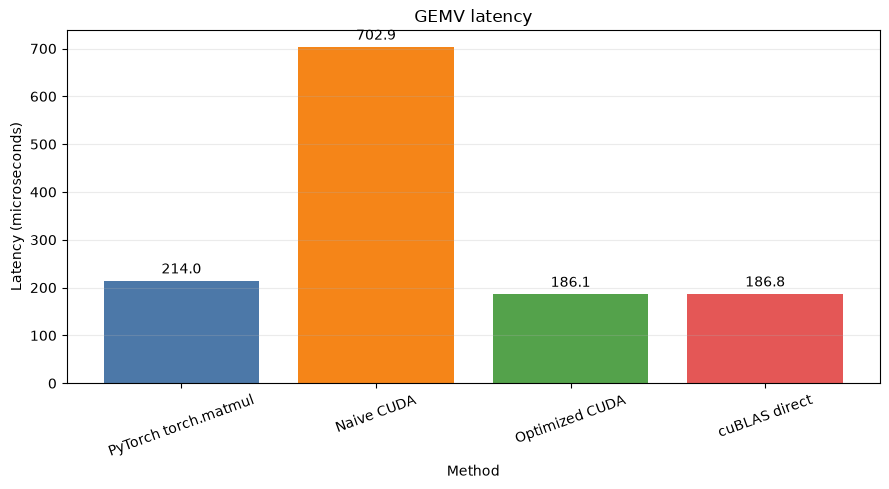

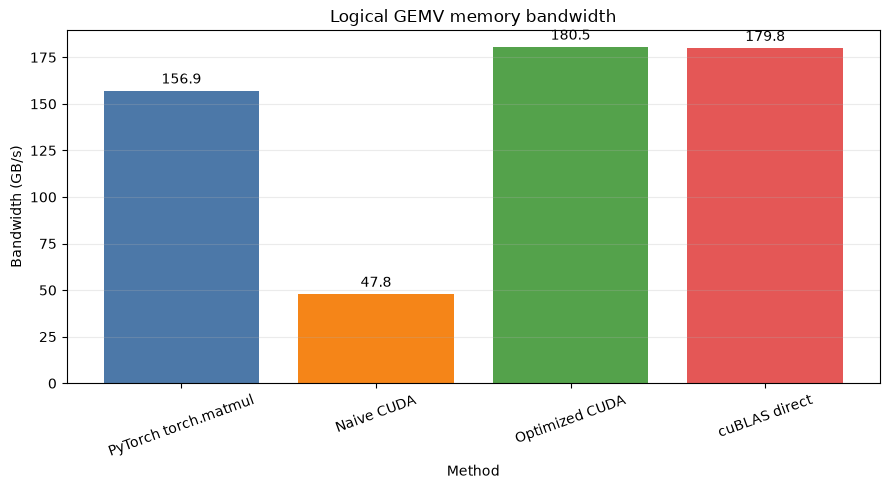

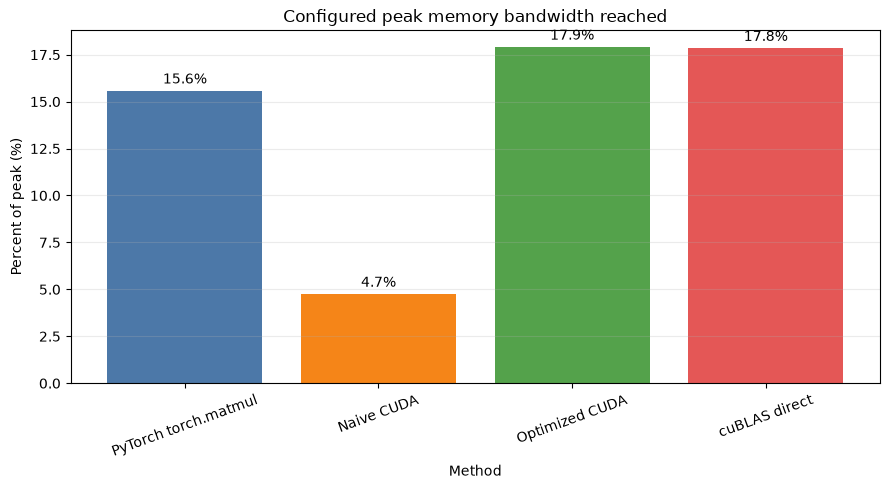

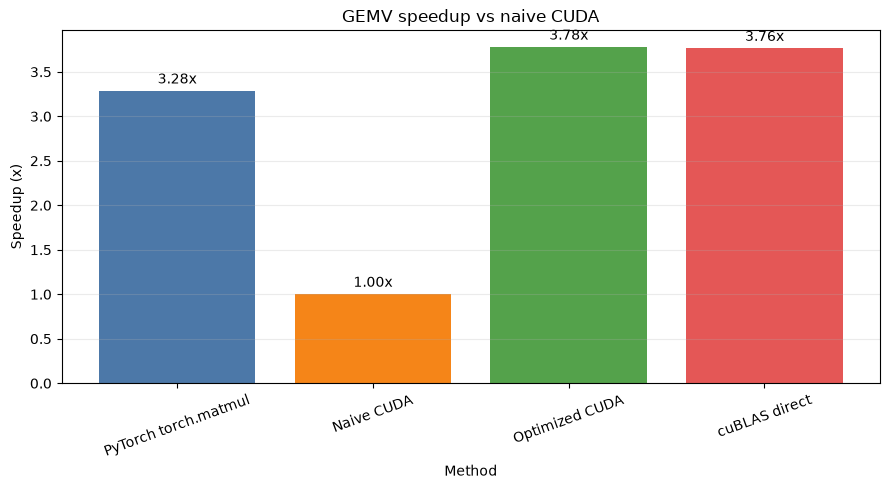

In [28]:
# import matplotlib.pyplot as plt

PLOT_SPECS = [
    ("latency_us", "GEMV latency", "Latency (microseconds)", "{:.1f}"),
    ("bandwidth_GBps", "Logical GEMV memory bandwidth", "Bandwidth (GB/s)", "{:.1f}"),
    (
        "percent_peak_bandwidth",
        "Configured peak memory bandwidth reached",
        "Percent of peak (%)",
        "{:.1f}%",
    ),
    ("speedup_vs_naive", "GEMV speedup vs naive CUDA", "Speedup (x)", "{:.2f}x"),
]

# One unique color per method
COLOR_PALETTE = [
    "#4C78A8",  # blue
    "#F58518",  # orange
    "#54A24B",  # green
    "#E45756",  # red
    "#72B7B2",  # teal
    "#B279A2",  # purple
    "#FF9DA6",  # pink
    "#9D755D",  # brown
    "#BAB0AC",  # gray
]

methods = results["method"].tolist()

method_colors = {
    method: COLOR_PALETTE[i % len(COLOR_PALETTE)]
    for i, method in enumerate(methods)
}

bar_colors = [method_colors[method] for method in methods]

for column, title, ylabel, value_format in PLOT_SPECS:
    fig, ax = plt.subplots(figsize=(9, 5))

    bars = ax.bar(
        results["method"],
        results[column],
        color=bar_colors,
    )

    ax.set_title(title)
    ax.set_xlabel("Method")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.25)

    ax.bar_label(
        bars,
        labels=[value_format.format(value) for value in results[column]],
        padding=3,
    )

    fig.tight_layout()
    plt.show()

## 13. Interpretation

GEMV is memory-bandwidth-bound because each weight is read once and reused very little.

For W[4096,4096] in fp16:

- weights read = 4096 × 4096 × 2 bytes ≈ 33.55 MB
- x read = 4096 × 2 bytes ≈ 8 KB
- y write = 4096 × 4 bytes ≈ 16 KB

The weight matrix dominates memory traffic, so the main optimization target is global memory bandwidth.

Naive CUDA is slow because one thread does a full row dot product serially. Optimized CUDA is faster because one block cooperatively computes a row using coalesced loads and parallel reduction. cuBLAS and PyTorch are strong baselines because they use vendor-tuned kernels.

The percentages below use PEAK_BANDWIDTH_GBPS, which defaults to 1008 GB/s for an RTX 4090. Change it to the printed GPU's sustained or specified bandwidth before interpreting the percentage. These are standalone kernel microbenchmark results; they do not by themselves establish an end-to-end LLM serving improvement.

In [27]:
optimized = results.loc[results["method"] == "Optimized CUDA"].iloc[0]
print(
    "The optimized CUDA kernel reaches "
    f"{optimized['bandwidth_GBps']:.2f} GB/s, which is "
    f"{optimized['percent_peak_bandwidth']:.2f}% of the configured peak "
    "memory bandwidth, and is "
    f"{optimized['speedup_vs_naive']:.2f}x faster than the naive CUDA implementation."
)

The optimized CUDA kernel reaches 180.45 GB/s, which is 17.90% of the configured peak memory bandwidth, and is 3.78x faster than the naive CUDA implementation.
